# Basins of attraction

Modified by [Moreno Marzolla](https://www.moreno.marzolla.name/) from code available [online](https://colab.research.google.com/github/mwelland/ENGPHYS_3NM4/blob/main/Book/Chapters/Root%20finding/Basins%20of%20attraction.ipynb).

Last modified May 2026.

---

## Newton's method

Newton's method is used to find the real solutions of the equation $f(x) = 0$ by iterating the function:

$$
x_{n+1} = x_n - \frac{f(x_x)}{f'(x_n)}
$$

starting form an initial guess $x_0$. In may cases, the orbit $x_0, x_1, \ldots$ converges towards a fixed point $\bar{x}$ that satisfies $f(\bar{x}) = 0$.

In general, convergence of Newton's method depends on the initial choice of $x_0$. There may be cases where bad choices of the initial guess $x_0$ lead to a sequence that enters a cycle without ever reaching a fixed points. In this notebook we are interested in another situation: suppose that $f(x)$ has $k$ distinct real roots, say $\bar{x}_0, \bar{x}_1, \ldots, \bar{x}_{k-1}$. We want to find out what are the **basins of attractions of each root**, that is, the set of initial guesses that leat to a particular root.

For example, let's take the function $f(x) = x^3 - x$ that has three real roots: $x=-1, 0, 1$. Here, we have $f'(x) = 3x^2 -1$, so Newton's method works by iterating:

$$
x_{n+1} = x_n - \frac{x^3-x}{3x^2-1}
$$

In [1]:
import numpy as np
import numpy.polynomial.polynomial as poly
import matplotlib.pyplot as plt
%matplotlib inline
#plt.rcParams['figure.dpi'] = 300
from scipy.optimize import newton

We use the [`poly.Polinomial()`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.html#numpy.polynomial.polynomial.Polynomial) Python object to represent $f$; `poly.Polynomial([a,b,c,d])` returns an object that represents the polynomial $a + bx + cx^2 + dx^3$, so $f(x) = -x + x^3$ is expressed as:

In [2]:
f = poly.Polynomial([0,-1,0,1]);

We can use [`newton(f, x0, fprime)`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html) from [`scipy.optimize`](https://docs.scipy.org/doc/scipy/tutorial/optimize.html) to apply Newton's method to function `f` with derivative `fprime`, using `x0` as initial guess. The derivative of a polynomial object `f` can be computed automatically using `f.deriv()`.

Let us try to see where Newton's method converges depending on the initial guess $x_0$. To do so, we plot the result of `newton(f, x0, fprime)` as a function of $x_0$.

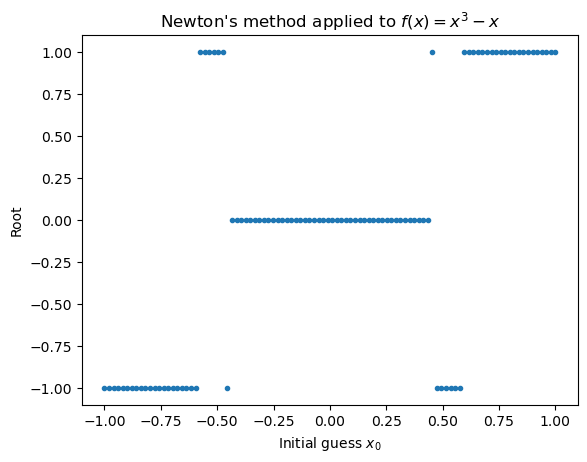

In [3]:
x0 = np.linspace(-1,1,100)
roots = newton(f, x0, fprime = f.deriv())
plt.plot(x0,roots,'.')
plt.title("Newton's method applied to $f(x) = x^3 -x$")
plt.xlabel("Initial guess $x_0$")
plt.ylabel("Root")
plt.show()

We see something interesting: the basins of attraction of the three roots $-1, 0, 1$ are disconnected. Let us zoom the range $x_0 = [-0,5, -0.4]$. 

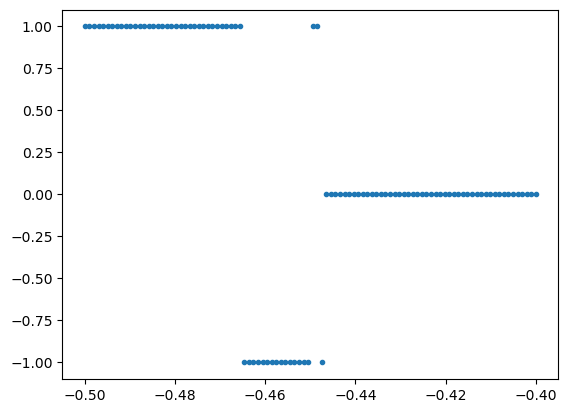

In [4]:
x0 = np.linspace(-0.5,-0.4,100)
roots = newton(f, x0, fprime = f.deriv())
plt.plot(x0,roots,'.')
plt.show()

Let us zoom again in $x_0 = [-0.46, -0.44]$.

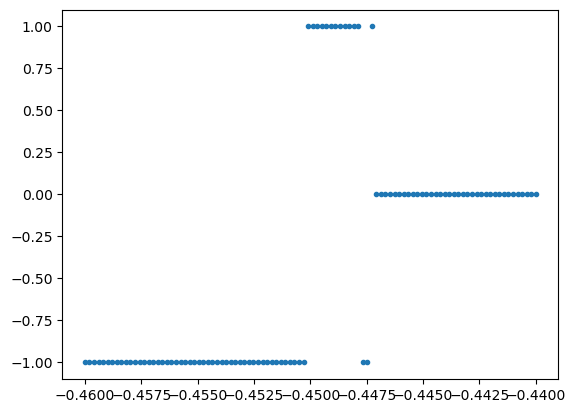

In [5]:
x0 = np.linspace(-0.46,-0.44,100)
roots = newton(f, x0, fprime = f.deriv())
plt.plot(x0,roots,'.')
plt.show()

We see that the more we zoom in, the more the frontiers of the basins of attraction look the same. There is a name for this, _fractal_. We will talk about that later on.

## Newton's method on the complex plane

Newton's method can be applied to functions on the complex plane as well. A complex number $x + iy$ corresponds to a point $(x,y)$ in the Cartesian plane. Therefore, the basins of attraction of Newton's method are regions of the complex plane. 

We define the `basins(f, roots)` function that draws the basins of attraction for the roots of polynomial `f`; the user must pass the vector of the true roots of `f` in the `roots` array.

In [6]:
def basins(f, roots = None, title = None, image_range = [-1.5, 1.5, -1.5, 1.5], grid_size = 1000):
    """ 
    Draw the basins of attraction of function f(z)=0; f(z) must be a polynomial.
    
    - roots is the array of roots of f(); if None, is computed automatically.
    - title is the title of the plot.
    - image_range are the ranges [xmin, xmax, ymin, ymax] of the image. 
      xmin, xmax are the real part, ymin, ymax are the imageinary part.
    - grid_size is the number of pixels per side.
    """
    # Create a grid of complex numbers
    real_values = np.linspace(image_range[0], image_range[1], grid_size)
    imag_values = np.linspace(image_range[2], image_range[3], grid_size)
    z_grid = np.array([[complex(r, i) for r in real_values] for i in imag_values])

    # Apply Newton-Raphson to each point in the grid
    roots_newton = newton(f, z_grid, fprime=f.deriv())

    # Assign colors based on the root found
    EPS = 1e-3
    roots = (f.roots() if roots is None else roots)
    colors = np.zeros((grid_size, grid_size))
    for i in range(grid_size):
      for j in range(grid_size):
        if roots_newton[i,j] is None:
            colors[i,j] = 0
        else:
            colors[i,j] = next((c for c,r in enumerate(roots) if abs(roots_newton[i,j] - r) < EPS), 0)

    # Plot the basins of attraction
    plt.imshow(colors, extent=image_range, origin='lower', cmap='Paired') #cmap='viridis')
    roots = np.array(roots)
    plt.plot(roots.real, roots.imag, "k.")
    plt.title(title)
    #plt.axis("off")
    #plt.savefig('basins-of-attraction.png', bbox_inches='tight', pad_inches=0)
    plt.show()

The first example is the polynomial $f(z) = z^3 - 1$, where $z$ is a complex number. The roots of $f$ are the complex cube roots of $1$, i.e.,

$$
\exp \left( \frac{2k\pi i}{3} \right) = \cos \frac{2k\pi}{3} + i \sin \frac{2k\pi}{3}, \qquad k=0, 1, 2
$$

Let us examine the basins of attractions of the three roots.

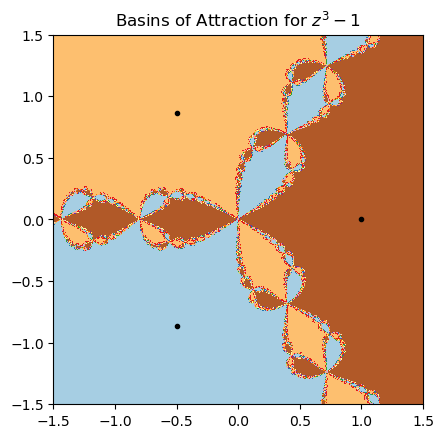

In [7]:
# roots = [np.exp(2*k*np.pi*1.j / 3) for k in [0, 1, 2]];

basins(f=poly.Polynomial([-1,0,0,1]), title="Basins of Attraction for $z^3 - 1$")

The black dots are the roots of $f$. We see that the boundaries have a very complex structure, that looks the same at different scales (we can verify that by zooming in).

Let us try another example: we compute the basins of attraction of Newton's method for $f(z) = z^3 - z$ on the complex plane. This polynomial has three real roots $[-1, 0, 1]$; the basins of attraction are the following.

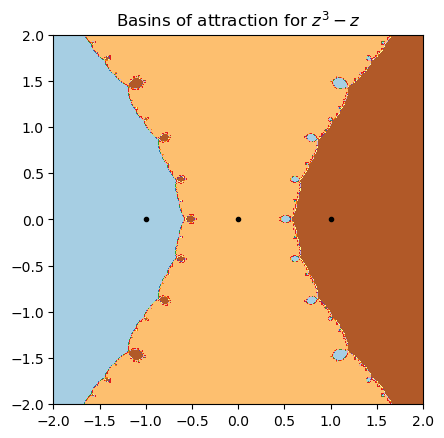

In [8]:
basins(f = poly.Polynomial([0,-1,0,1]),
       title="Basins of attraction for $z^3-z$", 
       roots=[-1, 0, 1],
       image_range=[-2, 2, -2, 2])